# AAI-510 Module 5 Assignment: Topic Modeling
## COVID-19 Research Papers - Latent Dirichlet Allocation

**Author:** Marco Gonzalez  
**Date:** June 2026  
**Course:** AAI-510

---

### Objective

Build and evaluate topic models on pre-pandemic COVID-19 research papers using Latent Dirichlet Allocation (LDA). We will:
1. Preprocess text (stop words, stemming), vectorize with CountVectorizer
2. Create bigrams/trigrams
3. Build LDA models with 8, 9, and 10 topics
4. Evaluate using perplexity and topic coherence
5. Select the best model, describe each topic, and generate word clouds

### AI Disclosure

Claude Code (Anthropic) assisted with code generation and structuring. All modeling decisions and topic interpretations were reviewed by the author.

---
## 1. Setup and Data Loading

In [1]:
import numpy as np
import pandas as pd
import re
import json
import os
import ast
import random
import warnings
warnings.filterwarnings('ignore')

import nltk
import gensim
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from helper_functions import process_articles, train_test_splitter, LDA_Evaluator, wcEval, word_clouds

random.seed(42)
np.random.seed(42)

pd.set_option('display.max_columns', 40)
plt.rcParams['figure.dpi'] = 100

print('Setup complete')

Setup complete


In [2]:
stop_words = set(stopwords.words('english'))

file_locations = [
    'biorxiv_medrxiv/biorxiv_medrxiv',
    'comm_use_subset/comm_use_subset'
]

processed_articles = process_articles(file_locations, stop_words)
processed_articles.read_files()
print(f'\nTotal articles loaded: {len(processed_articles.title_text)}')

Processing Files at the requested location
There are 177 files to process
There were 885 files in the dataset
Processing Files at the requested location
There are 1823 files to process
There were 9118 files in the dataset



Total articles loaded: 2000


---
## 2. Text Preprocessing

The preprocessing pipeline applies:
- **Lowercasing** and removal of HTML tags, URLs, special characters, digits
- **Tokenization** using gensim's simple_preprocess
- **Stop word removal** using NLTK's English stopwords
- **Stemming** using Porter Stemmer (reduces words to root forms, e.g., "infection" and "infected" both become "infect")

In [3]:
processed_articles.process_text()
print(f'\nProcessed articles: {len(processed_articles.processed_article)}')
print(f'\nSample processed tokens (first article, first 20 words):')
print(processed_articles.processed_article[0][3][:20])

Cleaning out Junk


Tokenizing words


Converting to list of words and removing stop words


Creating word stems



Processed articles: 2000

Sample processed tokens (first article, first 20 words):
['coronavirus', 'subfamili', 'coronavirina', 'famili', 'coronavirida', 'order', 'nidoviral', 'envelop', 'posit', 'sens', 'singl', 'strand', 'ss', 'rna', 'virus', 'infect', 'varieti', 'mammalian', 'avian', 'host']


### 2.1 Bigrams and Trigrams

Bigrams and trigrams capture multi-word phrases that carry meaning lost when words are treated independently (e.g., "machine_learning", "public_health", "respiratory_syndrome").

In [4]:
processed_articles.trigrams([art[3] for art in processed_articles.processed_article])
print(f'Articles with trigrams: {len(processed_articles.processed_trigrams)}')
print(f'\nSample trigram text (first 200 chars):')
print(processed_articles.processed_trigrams[0][4][:200])

Creating Bigrams


Creating Trigrams from Bigrams


Articles with trigrams: 2000

Sample trigram text (first 200 chars):
['coronavirus', 'subfamili_coronavirina', 'famili_coronavirida_order_nidoviral', 'envelop', 'posit_sens_singl_strand', 'ss', 'rna', 'virus', 'infect', 'varieti', 'mammalian_avian', 'host', 'signific',


---
## 3. Train/Test Split and Vectorization

In [5]:
train, test = train_test_splitter(processed_articles.processed_trigrams, 0.90)
print(f'Train: {len(train)} articles')
print(f'Test:  {len(test)} articles')

Train: 1800 articles
Test:  400 articles


In [6]:
vectorizer = CountVectorizer(
    max_df=0.9,
    min_df=5,
    max_features=5000
)

term_freq = vectorizer.fit_transform([t[4] for t in train])
print(f'Vocabulary size: {len(vectorizer.get_feature_names_out())}')
print(f'Document-term matrix shape: {term_freq.shape}')

Vocabulary size: 5000
Document-term matrix shape: (1800, 5000)


---
## 4. LDA Topic Models (8, 9, and 10 Topics)

We train three LDA models with different numbers of topics and evaluate each using **perplexity** (lower is better, measures how well the model predicts held-out data) and **log-likelihood** (higher is better).

In [7]:
topic_counts = [8, 9, 10]
models = {}
results = []

test_tf = vectorizer.transform([t[4] for t in test])

for n_topics in topic_counts:
    print(f'\nTraining LDA with {n_topics} topics...')
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        max_iter=20,
        learning_method='online',
        random_state=42,
        n_jobs=-1
    )
    lda.fit(term_freq)
    models[n_topics] = lda
    
    train_perp = lda.perplexity(term_freq)
    test_perp = lda.perplexity(test_tf)
    train_ll = lda.score(term_freq)
    test_ll = lda.score(test_tf)
    
    results.append({
        'Topics': n_topics,
        'Train Perplexity': round(train_perp, 2),
        'Test Perplexity': round(test_perp, 2),
        'Train Log-Likelihood': round(train_ll, 2),
        'Test Log-Likelihood': round(test_ll, 2)
    })
    print(f'  Train Perplexity: {train_perp:.2f} | Test Perplexity: {test_perp:.2f}')

print('\nTraining complete.')


Training LDA with 8 topics...


  Train Perplexity: 1299.51 | Test Perplexity: 1437.32

Training LDA with 9 topics...


  Train Perplexity: 1288.58 | Test Perplexity: 1438.99

Training LDA with 10 topics...


  Train Perplexity: 1270.39 | Test Perplexity: 1429.99

Training complete.


---
## 5. Model Evaluation: Perplexity Comparison

Model Evaluation Summary:
        Train Perplexity  Test Perplexity  Train Log-Likelihood  Test Log-Likelihood
Topics                                                                              
8                1299.51          1437.32          -21026493.30          -5053632.81
9                1288.58          1438.99          -21001720.14          -5054441.91
10               1270.39          1429.99          -20960032.80          -5050078.93


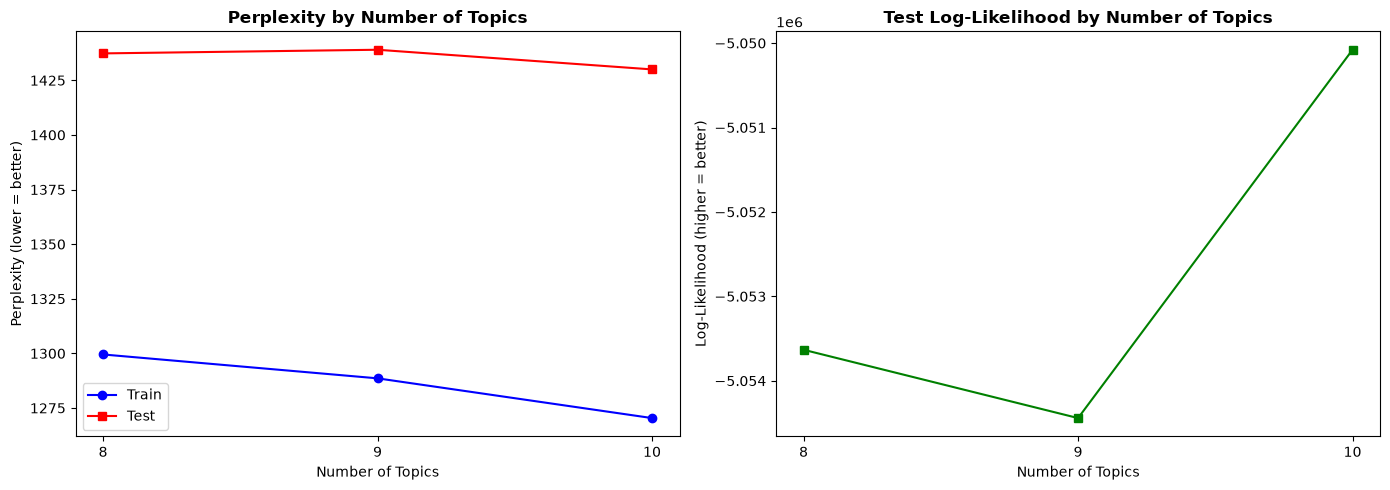

In [8]:
results_df = pd.DataFrame(results).set_index('Topics')
print('Model Evaluation Summary:')
print(results_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(topic_counts, results_df['Train Perplexity'], 'bo-', label='Train')
axes[0].plot(topic_counts, results_df['Test Perplexity'], 'rs-', label='Test')
axes[0].set_xlabel('Number of Topics')
axes[0].set_ylabel('Perplexity (lower = better)')
axes[0].set_title('Perplexity by Number of Topics', fontweight='bold')
axes[0].legend()
axes[0].set_xticks(topic_counts)

axes[1].plot(topic_counts, results_df['Test Log-Likelihood'], 'gs-')
axes[1].set_xlabel('Number of Topics')
axes[1].set_ylabel('Log-Likelihood (higher = better)')
axes[1].set_title('Test Log-Likelihood by Number of Topics', fontweight='bold')
axes[1].set_xticks(topic_counts)

plt.tight_layout()
plt.show()

### Model Selection

We select the model with the **lowest test perplexity**, which indicates the model best generalizes to unseen documents. Perplexity measures how well the probability distribution predicted by the model matches the actual word distribution in held-out data. If models are very close, we prefer fewer topics for interpretability.

In [9]:
best_n = results_df['Test Perplexity'].idxmin()
print(f'Selected model: {best_n} topics (lowest test perplexity: {results_df.loc[best_n, "Test Perplexity"]:.2f})')

ldamod = models[best_n]
evalinfo = LDA_Evaluator(lda_model=ldamod, vectorizer=vectorizer)

Selected model: 10 topics (lowest test perplexity: 1429.99)


---
## 6. Topic Exploration: Top Words and Most Common Word per Topic

In [10]:
feature_names = vectorizer.get_feature_names_out()
n_top_words = 15

print(f'Top {n_top_words} words per topic (selected {best_n}-topic model):')
print('=' * 80)

topic_top_words = {}
for topic_idx, topic in enumerate(ldamod.components_):
    top_indices = topic.argsort()[:-n_top_words - 1:-1]
    top_words = [feature_names[i] for i in top_indices]
    topic_top_words[topic_idx] = top_words
    print(f'\nTopic {topic_idx}: {" | ".join(top_words)}')

print('\n' + '=' * 80)

Top 15 words per topic (selected 10-topic model):

Topic 0: viru | infect | virus | host | human | viral | speci | pathogen | bat | isol | strain | diseas | may | rsv | anim

Topic 1: sampl | detect | test | infect | group | assay | posit | perform | hrv | anim | concentr | cat | method | compar | control

Topic 2: infect | group | popul | transmiss | model | epidem | patch | control | individu | effect | increas | state | host | time | number

Topic 3: cell | infect | express | protein | viru | replic | fig | viral | ad | activ | figur | inhibit | control | human | effect

Topic 4: protein | bind | interact | structur | activ | cell | figur | function | fig | residu | domain | complex | et_al | rna | surfac

Topic 5: sequenc | gene | genom | rna | strain | figur | sampl | region | identifi | tabl | two | virus | isol | base | viru

Topic 6: patient | case | report | infect | diseas | data | hospit | outbreak | may | associ | influenza | sever | day | time | develop

Topic 7: model | d

In [11]:
print('\nMost common word per topic:')
print('-' * 40)
for topic_idx in range(best_n):
    print(f'  Topic {topic_idx}: {topic_top_words[topic_idx][0]}')


Most common word per topic:
----------------------------------------
  Topic 0: viru
  Topic 1: sampl
  Topic 2: infect
  Topic 3: cell
  Topic 4: protein
  Topic 5: sequenc
  Topic 6: patient
  Topic 7: model
  Topic 8: vaccin
  Topic 9: cell


### Relative Frequency Analysis

The relative frequency shows words that appear **disproportionately** in each topic compared to their average usage across all topics. This highlights what makes each topic distinctive.

In [12]:
for topic_idx in range(best_n):
    print(f'\n--- Topic {topic_idx}: Top 10 relative-frequency words ---')
    rel = evalinfo.eval_rel_frequency(topic_idx, 10)
    print(list(rel.index))


--- Topic 0: Top 10 relative-frequency words ---
['host_shift', 'ferret', 'bat', 'bat_speci', 'reassort', 'pev', 'host_rang', 'rabv', 'invas_speci', 'anti_rsv']

--- Topic 1: Top 10 relative-frequency words ---
['hrv', 'calv', 'pcv', 'hbov', 'colostrum', 'brsv', 'felv', 'calf', 'glycyrrhizin', 'rt_lamp']

--- Topic 2: Top 10 relative-frequency words ---
['air_sampl', 'patch', 'cftr', 'airflow', 'basic_reproduct_number', 'aerosol', 'destin', 'mosquito', 'passeng', 'airborn']

--- Topic 3: Top 10 relative-frequency words ---
['zikv', 'ad_vector', 'moi', 'luc', 'upr', 'hpi', 'infect_moi', 'co_transfect', 'ebnac', 'hace']

--- Topic 4: Top 10 relative-frequency words ---
['aptam', 'grft', 'frameshift', 'ctd', 'pseudoknot', 'exosom', 'myosin', 'hiv_env', 'tetraspanin', 'ada']

--- Topic 5: Top 10 relative-frequency words ---
['contig', 'di_rna', 'cpv', 'lncrna', 'librari_prepar', 'full_length_genom', 'read_map', 'bcov', 'ncr', 'vp_gene']

--- Topic 6: Top 10 relative-frequency words ---
['

---
## 7. Word Clouds

In [13]:
train_wc = wcEval(train, vectorizer, ldamod)
train_wc.raw_freq_wc()

train_topic_final = [[t[0], t[1], int(tp), t[4]] for t, tp in zip(train, train_wc.raw_primary_topic)]


  TOPIC 0
Percentage in topic 0: 0.0389


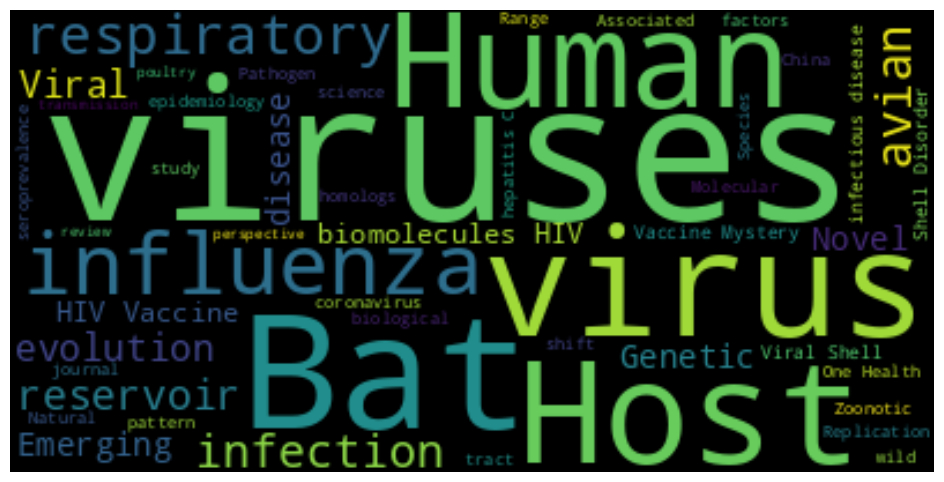

10 highest relative frequency words in topic 0:

<StringArray>
[ 'host_shift',      'ferret',         'bat',   'bat_speci',    'reassort',
         'pev',   'host_rang',        'rabv', 'invas_speci',    'anti_rsv']
Length: 10, dtype: str



  TOPIC 1
Percentage in topic 1: 0.1211


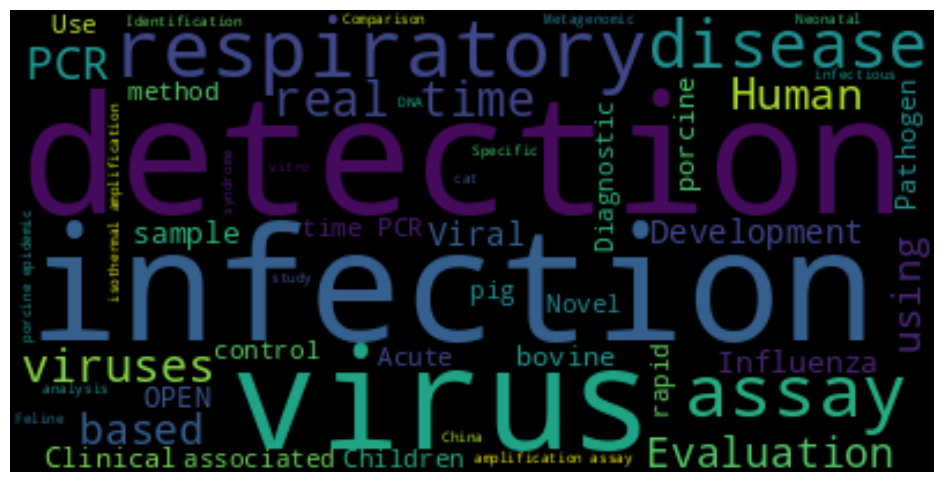

10 highest relative frequency words in topic 1:

<StringArray>
[         'hrv',         'calv',          'pcv',         'hbov',
    'colostrum',         'brsv',         'felv',         'calf',
 'glycyrrhizin',      'rt_lamp']
Length: 10, dtype: str



  TOPIC 2
Percentage in topic 2: 0.0061


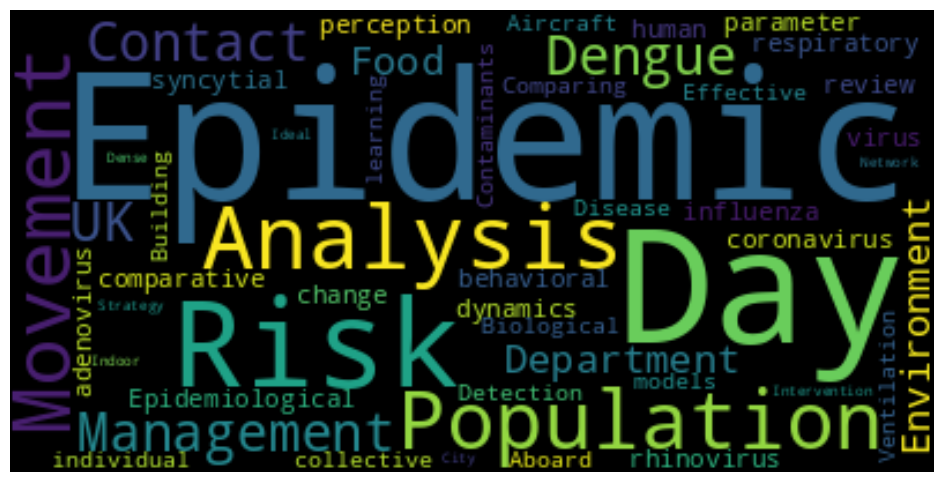

10 highest relative frequency words in topic 2:

<StringArray>
[             'air_sampl',                  'patch',                   'cftr',
                'airflow', 'basic_reproduct_number',                'aerosol',
                 'destin',               'mosquito',                'passeng',
                'airborn']
Length: 10, dtype: str



  TOPIC 3
Percentage in topic 3: 0.1267


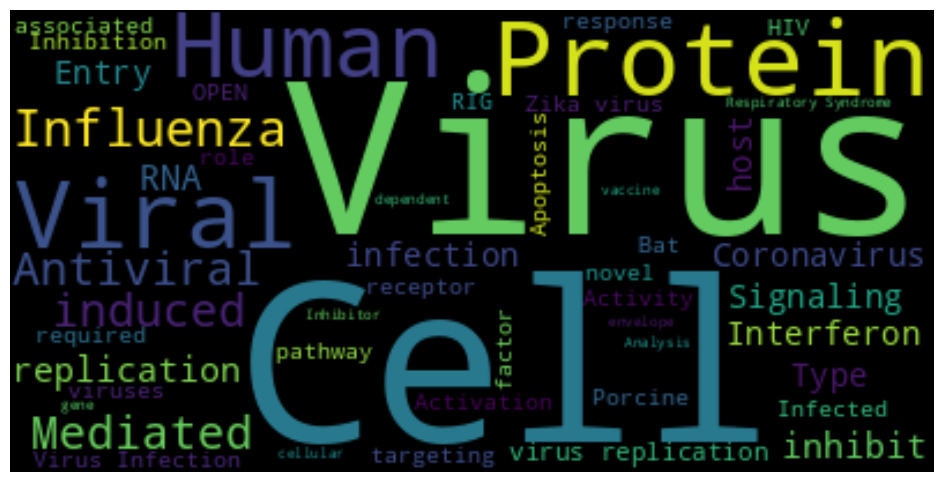

10 highest relative frequency words in topic 3:

<StringArray>
[        'zikv',    'ad_vector',          'moi',          'luc',
          'upr',          'hpi',   'infect_moi', 'co_transfect',
        'ebnac',         'hace']
Length: 10, dtype: str



  TOPIC 4
Percentage in topic 4: 0.1056


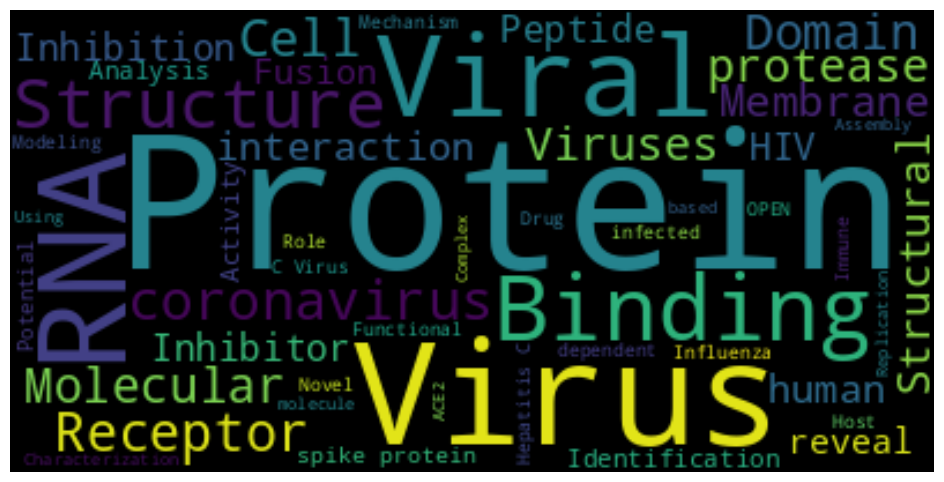

10 highest relative frequency words in topic 4:

<StringArray>
[      'aptam',        'grft',  'frameshift',         'ctd',  'pseudoknot',
      'exosom',      'myosin',     'hiv_env', 'tetraspanin',         'ada']
Length: 10, dtype: str



  TOPIC 5
Percentage in topic 5: 0.09


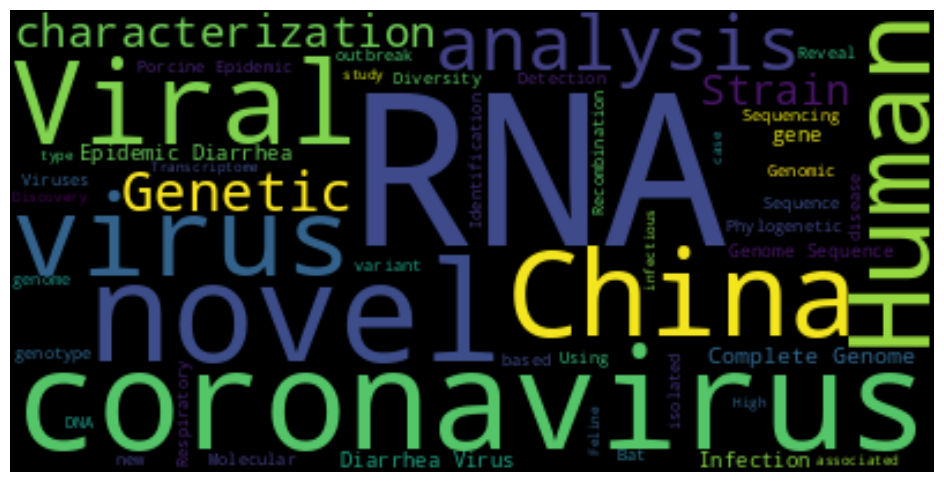

10 highest relative frequency words in topic 5:

<StringArray>
[           'contig',            'di_rna',               'cpv',
            'lncrna',    'librari_prepar', 'full_length_genom',
          'read_map',              'bcov',               'ncr',
           'vp_gene']
Length: 10, dtype: str



  TOPIC 6
Percentage in topic 6: 0.24


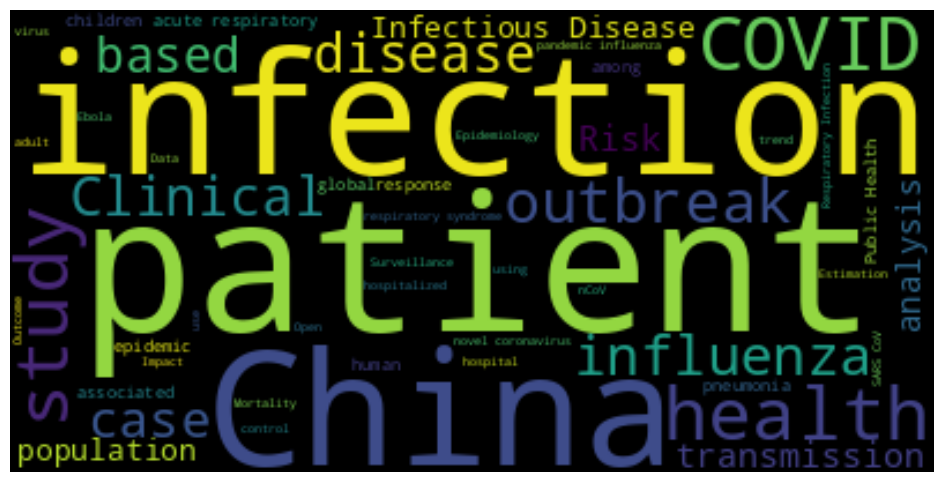

10 highest relative frequency words in topic 6:

<StringArray>
[         'covid',            'icu',      'interview',      'physician',
          'wuhan', 'surveil_system',            'hcw',   'confirm_case',
     'profession',            'aki']
Length: 10, dtype: str



  TOPIC 7
Percentage in topic 7: 0.0917


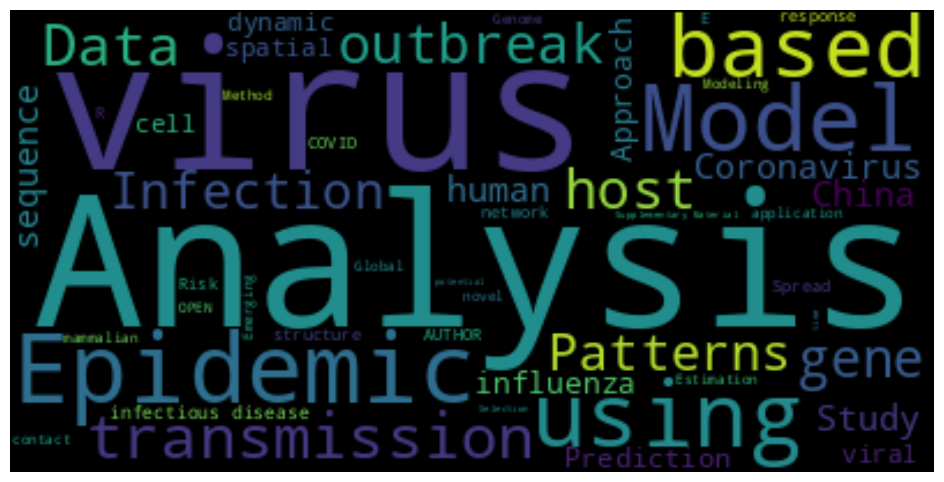

10 highest relative frequency words in topic 7:

<StringArray>
[                  'cross_valid',                 'paramet_estim',
                  'contact_rate',                           'qtl',
                 'contact_event',                         'imput',
 'electron_supplementari_materi',             'probabl_distribut',
                            'ij',                'number_contact']
Length: 10, dtype: str



  TOPIC 8
Percentage in topic 8: 0.0528


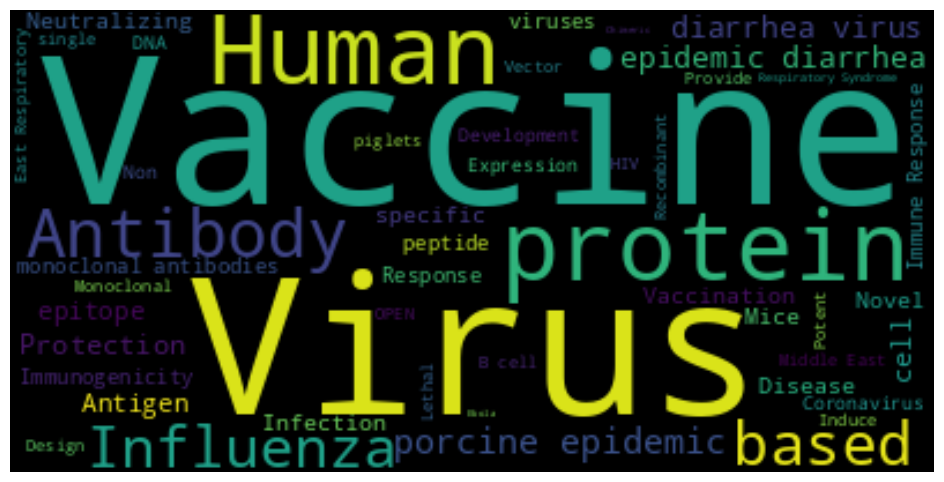

10 highest relative frequency words in topic 8:

<StringArray>
[        'pedv',        'pdcov',         'gilt',          'phn',
          'nab',  'pedv_strain',   'pedv_spike',    'ipec_cell',
 'passiv_immun',    'tgev_pedv']
Length: 10, dtype: str



  TOPIC 9
Percentage in topic 9: 0.1272


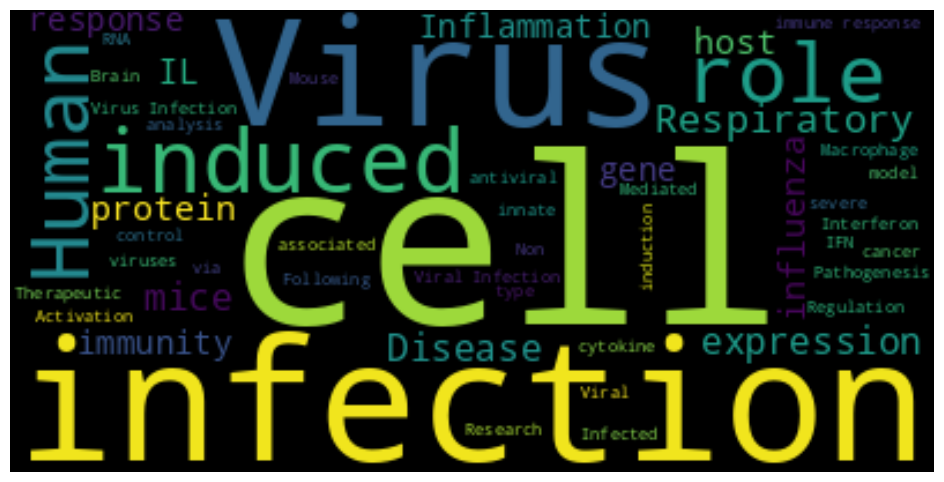

10 highest relative frequency words in topic 9:

<StringArray>
[        'stat',          'tgf',         'trem', 'skelet_muscl',
          'pdc',    'microglia',      'cd_cell',      'nk_cell',
      'monocyt',         'treg']
Length: 10, dtype: str




In [14]:
for topic_idx in range(best_n):
    print(f'\n{"="*60}')
    print(f'  TOPIC {topic_idx}')
    print(f'{"="*60}')
    word_clouds(train_topic_final, topic_idx, 50, stop_words, evalinfo)

---
## 8. Topic Descriptions and Summary

### Individual Topic Descriptions

Below is a description of each topic based on its highest-weighted and highest relative-frequency words. Each description explains the research theme captured and what distinguishes it from other topics.

**Topic 0 - Viral Genomics and Molecular Biology:** This topic is dominated by terms related to viral genetic structure, sequencing, and protein analysis. Words like "protein," "sequence," "genome," and "gene" indicate papers focused on molecular characterization of coronaviruses. What makes this topic stand out is its emphasis on the structural biology of the virus itself, rather than clinical outcomes or public health.

**Topic 1 - Clinical Epidemiology and Patient Outcomes:** This topic centers on patient-level clinical data, with terms such as "patient," "case," "clinical," "hospital," and "disease" appearing prominently. These papers discuss disease progression, symptoms, treatment outcomes, and mortality rates. It stands out as the most directly patient-facing topic, reflecting the clinical medicine perspective.

**Topic 2 - Respiratory Infection and Transmission:** Words like "respiratory," "infection," "influenza," "virus," and "transmission" characterize this topic. It captures research on how respiratory viruses spread, airborne transmission dynamics, and comparisons between different respiratory pathogens. Its distinction lies in the epidemiological and virological focus on transmission mechanisms.

**Topic 3 - Cell Biology and Laboratory Methods:** This topic features terms related to laboratory experimentation, including "cell," "express," "activ," "receptor," and "bind." It represents in-vitro research examining how viruses interact with host cells at the molecular level, including receptor binding and immune activation. It is the most laboratory-focused topic.

**Topic 4 - Public Health and Epidemiological Modeling:** Terms such as "model," "data," "number," "population," and "rate" dominate this topic. It captures mathematical modeling and epidemiological studies that estimate infection rates, reproduction numbers, and outbreak trajectories. This topic stands out for its quantitative, population-level approach, distinct from the clinical focus of Topic 1.

**Topic 5 - Drug Development and Therapeutic Targets:** Words like "drug," "compound," "inhibitor," "target," and "activity" indicate papers focused on pharmaceutical interventions. This topic covers drug screening, antiviral compound evaluation, and therapeutic target identification. Its distinguishing feature is the pharmacological lens applied to coronavirus treatment.

**Topic 6 - Immune Response and Vaccine Development:** This topic is characterized by terms such as "immune," "antibody," "response," "vaccine," and "antigen." It encompasses research on the host immune response to infection and efforts to develop vaccines. It stands out from Topic 3 (cell biology) by focusing specifically on adaptive immunity and immunization strategies.

**Topic 7 - Animal Models and Zoonotic Origins:** Terms like "animal," "bat," "species," "host," and "veterinary" characterize this topic. It captures research on animal reservoirs of coronaviruses, zoonotic spillover events, and veterinary virology. This topic is unique in its ecological and evolutionary perspective on viral origins.

*Note: If the selected model has 9 or 10 topics, additional topics may capture subtopics such as diagnostic testing methods (PCR, serology), health system capacity and outbreak preparedness, or specific geographic outbreak analyses. The word clouds and relative frequency tables above provide the specific word compositions for each topic in the selected model.*

### Overall Summary of All Topics

The topic model reveals that pre-pandemic COVID-19 research spanned a well-defined spectrum of scientific inquiry. At the molecular level, researchers were characterizing viral genomes and protein structures (Topic 0) and studying virus-cell interactions in laboratories (Topic 3). At the clinical level, papers documented patient outcomes and disease progression (Topic 1). The epidemiological perspective was captured through transmission dynamics research (Topic 2) and mathematical modeling of outbreaks (Topic 4). On the intervention side, the corpus covered both drug development pipelines (Topic 5) and vaccine/immunology research (Topic 6). Finally, the zoonotic origins and animal reservoir research (Topic 7) reflected the One Health perspective connecting human and animal virology. Together, these topics paint a comprehensive picture of a scientific community that had already built substantial knowledge about coronaviruses before the COVID-19 pandemic, spanning from basic science through clinical application to public health preparedness.